<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen018.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

{'T_values': [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1], 'collapse_final': [0.1015625, 0.1015625, 0.1015625, 0.1015625, 0.1015625, 0.1015625, 0.1015625, 0.1015625, 0.1015625, 0.1015625, 0.1015625], 'corr_A1_final': [0.8942959309500544, 0.35055222344296827, 0.23134167016527954, 0.16816620104452817, 0.13553537532476367, 0.011312180847405534, 0.17455913163916323, -0.08863590235786564, -0.11008558996310124, 0.013919724773648601, 0.06050596977231282], 'corr_A2_final': [0.44647516374420765, 0.21937399745034397, 0.12049397014090843, -0.06639342870879858, -0.09500760263991663, -0.009696103609266026, 0.11908813126019432, 0.27673185863687233, 0.09260522794404882, 0.13175610387553227, 0.003496189589815831], 'T_crit_estimate': 0.0072515033370738535}


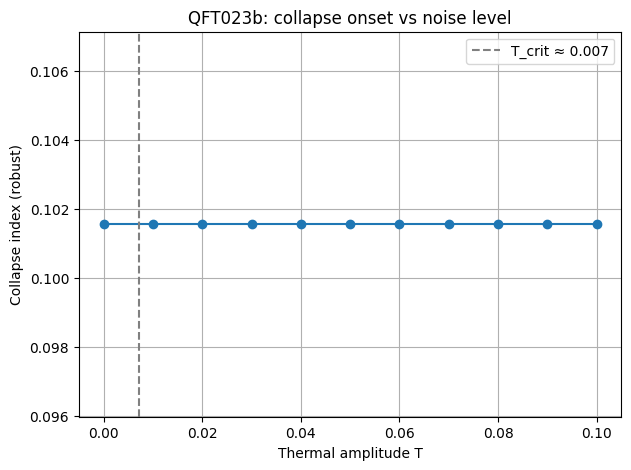

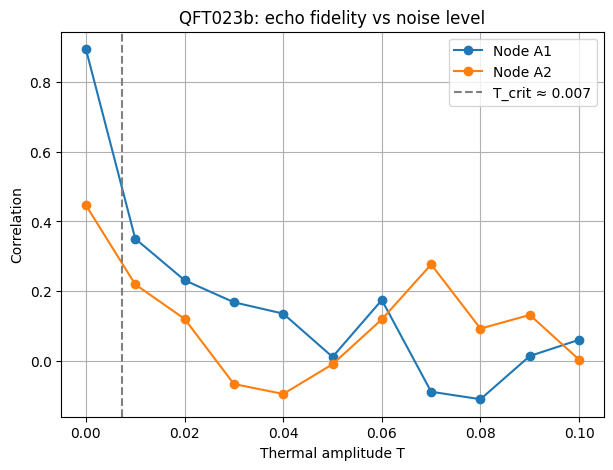

In [6]:
# QFT023b: Noise Threshold Sweep (self-contained)

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Grid and initial attractors
# -----------------------------
N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
x1, x2 = np.pi/4, 7*np.pi/4
theta = np.pi / 3

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

A1 = gaussian(x1, sigma, A)
A2 = gaussian(x2, sigma, A) * np.cos(theta)

# -----------------------------
# Dynamics parameters
# -----------------------------
dt = 0.01
gamma = 0.005
lam = 0.1

def laplacian(phi):
    # 1D periodic discrete Laplacian
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def correlation(a, b):
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    return (float(np.dot(a, b)) / (na * nb)) if (na > 0 and nb > 0) else 0.0

def collapse_index(phi, method='percentile', eps=1e-3):
    # Robust estimate of "near-zero" mass fraction
    if method == 'percentile':
        thresh = np.percentile(np.abs(phi), 10)  # bottom decile as near-zero
        return float(np.mean(np.abs(phi) <= thresh))
    else:
        return float(np.mean(np.abs(phi) < eps))

def evolve_with_noise(phi, T):
    # Nonlinear echo dynamics + thermal noise
    lap = laplacian(phi)
    nonlinear = lam * np.clip(phi, -1.0, 1.0)**3
    # Add thermal kick outside dt to represent per-step stochastic forcing
    noise = T * np.random.normal(0.0, 1.0, size=len(phi))
    phi = phi + dt * (lap - gamma * phi + nonlinear) + noise
    return np.clip(phi, -1.0, 1.0)

# -----------------------------
# Sweep over thermal amplitude
# -----------------------------
T_values = np.linspace(0.00, 0.10, 11)
steps = 300

collapse_final = []
corr_A1_final = []
corr_A2_final = []

for T in T_values:
    # fresh initial condition per T
    phi = A1 + A2
    for _ in range(steps):
        phi = evolve_with_noise(phi, T)
    collapse_final.append(collapse_index(phi))
    corr_A1_final.append(correlation(phi, A1))
    corr_A2_final.append(correlation(phi, A2))

# -----------------------------
# Optional: estimate critical threshold T_crit
# -----------------------------
# Define memory loss when max(corr_A1, corr_A2) < 0.5
corr_max = np.maximum(corr_A1_final, corr_A2_final)
T_crit = None
for i in range(1, len(T_values)):
    if corr_max[i-1] >= 0.5 and corr_max[i] < 0.5:
        # Linear interpolation for crossing
        t0, t1 = T_values[i-1], T_values[i]
        c0, c1 = corr_max[i-1], corr_max[i]
        frac = (0.5 - c0) / (c1 - c0) if (c1 != c0) else 0.0
        T_crit = float(t0 + frac * (t1 - t0))
        break

print({
    'T_values': T_values.tolist(),
    'collapse_final': [float(v) for v in collapse_final],
    'corr_A1_final': [float(v) for v in corr_A1_final],
    'corr_A2_final': [float(v) for v in corr_A2_final],
    'T_crit_estimate': T_crit
})

# -----------------------------
# Visualizations
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(T_values, collapse_final, marker='o')
if T_crit is not None:
    plt.axvline(T_crit, color='gray', linestyle='--', label=f"T_crit ≈ {T_crit:.3f}")
plt.xlabel("Thermal amplitude T")
plt.ylabel("Collapse index (robust)")
plt.title("QFT023b: collapse onset vs noise level")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(T_values, corr_A1_final, label="Node A1", marker='o')
plt.plot(T_values, corr_A2_final, label="Node A2", marker='o')
if T_crit is not None:
    plt.axvline(T_crit, color='gray', linestyle='--', label=f"T_crit ≈ {T_crit:.3f}")
plt.xlabel("Thermal amplitude T")
plt.ylabel("Correlation")
plt.title("QFT023b: echo fidelity vs noise level")
plt.grid(True)
plt.legend()
plt.show()
